## Modelo de Regresión Logística

In [71]:
#Importación de las librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [72]:
#Revisión del balance de las clases
intrusion_encoded = pd.read_csv(r"C:\Users\ntama\Documentos\Data Science\Gen Data\Prueba\prueba-gendata\data\intrusion_encoded.csv")
print(intrusion_encoded['attack_detected'].value_counts(1))

attack_detected
0    0.552899
1    0.447101
Name: proportion, dtype: float64


Las clases están aceptablemente balanceadas

In [73]:
#Importación de los datos de entrenamiento y prueba
predictors_train = pd.read_csv(r"C:\Users\ntama\Documentos\Data Science\Gen Data\Prueba\prueba-gendata\data\predictors_train.csv")
predictors_test = pd.read_csv(r"C:\Users\ntama\Documentos\Data Science\Gen Data\Prueba\prueba-gendata\data\predictors_test.csv")
labels_train = pd.read_csv(r"C:\Users\ntama\Documentos\Data Science\Gen Data\Prueba\prueba-gendata\data\labels_train.csv")
labels_test = pd.read_csv(r"C:\Users\ntama\Documentos\Data Science\Gen Data\Prueba\prueba-gendata\data\labels_test.csv")


Primera corrida del modelo

In [74]:

from sklearn.linear_model import LogisticRegression
logr = LogisticRegression(penalty=None, fit_intercept=True)
logr.fit(predictors_train, labels_train.values.ravel())
score_train = logr.score(predictors_train, labels_train)
score_test = logr.score(predictors_test, labels_test)

In [75]:
#Matriz de confusión
labels_test_predict = logr.predict(predictors_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(labels_test, labels_test_predict))

[[824 218]
 [366 500]]


- TP = 824
- FP = 366
- FN = 218
- TN = 500

Métricas de la primera iteración en los datos de prueba

In [76]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print(f"Accuracy Score, % total de predicciones correctas sobre todos los casos: {accuracy_score(labels_test, labels_test_predict)}")
print(f"Precision Score, % de positivos predichos por el modelo: {precision_score(labels_test, labels_test_predict)}")
print(f"Recall score % de positivos encontrados por el modelo respecto a los reales: {recall_score(labels_test, labels_test_predict)}")
print(f"f1 score: {f1_score(labels_test, labels_test_predict)}")


Accuracy Score, % total de predicciones correctas sobre todos los casos: 0.6939203354297694
Precision Score, % de positivos predichos por el modelo: 0.6963788300835655
Recall score % de positivos encontrados por el modelo respecto a los reales: 0.5773672055427251
f1 score: 0.6313131313131313


Métricas de la primera iteración en los datos de entrenamiento

In [77]:
labels_train_predict = logr.predict(predictors_train)
print(f"Accuracy Score, % total de predicciones correctas sobre todos los casos: {accuracy_score(labels_train, labels_train_predict)}")
print(f"Precision Score, % de positivos predichos por el modelo: {precision_score(labels_train, labels_train_predict)}")
print(f"Recall score % de positivos encontrados por el modelo respecto a los reales: {recall_score(labels_train, labels_train_predict)}")
print(f"f1 score: {f1_score(labels_train, labels_train_predict)}")

Accuracy Score, % total de predicciones correctas sobre todos los casos: 0.6909162406606371
Precision Score, % de positivos predichos por el modelo: 0.6736806947227789
Recall score % de positivos encontrados por el modelo respecto a los reales: 0.5935844614479105
f1 score: 0.6311013767209012


Modelo sin overfitting al comportarse de manera similar en entrenamiento y prueba

#### Optimización del parámetro C con GridSearch Cross-Validation para regularización L1 Ridge

In [78]:
from sklearn.model_selection import GridSearchCV
C_array = np.logspace(-3, 2, 100)
tuning_c = {'C': C_array}
clf = LogisticRegression(penalty='l1', solver='liblinear')
gs = GridSearchCV(clf, param_grid=tuning_c, scoring='recall', cv=5)
gs.fit(predictors_train, labels_train.values.ravel()) 

print("Mejor C:", gs.best_params_)
print("Mejor recall (CV):", gs.best_score_)

Mejor C: {'C': 0.002257019719633919}
Mejor recall (CV): 0.6989474140171532


Regularización L1 incrementa el recall </br>
Recall= TP/(TP + FN)</br>
Conviene reducir los Falsos Negativos</br>
​
 


#### El comportamiento ideal del modelo será el no pasar por alto ningún ataque cibernético (Recall alto)

Ajuste del umbral de predicción

In [79]:
labels_test_predict_prob = logr.predict_proba(predictors_test)[:,1]

umbrales = np.linspace(0.01, 0.99, 100)
falsos_negativos = []

for u in umbrales:
    y_pred = (labels_test_predict_prob >= u).astype(int)
    cm = confusion_matrix(labels_test, y_pred)
    fn = cm[1, 0]
    falsos_negativos.append(fn)

falsos_negativos = np.array(falsos_negativos)
idx = np.argmin(falsos_negativos)  # Umbral con menor cantidad de FN
umbral_elegido = umbrales[idx]
print(f"Umbral elegido para minimizar falsos negativos (maximizar recall): {umbral_elegido:.2f}")

Umbral elegido para minimizar falsos negativos (maximizar recall): 0.01


Con un umbral de 0.01 (1%) 99% de las sesiones serían clasificadas como ataqus (incremento de falsos positivos) </br>
Evaluación de las siguientes curvas:</br>
- Curva ROC + AUC para comportamiento del modelo

- Umbral vs F1 Score: importa detectar positivos (recall) sin disparar muchos falsos positivos (precisión)</br>
F1 = 2x[precision*recall/(precision+recall)]</br>
Buscar el umbral que maximiza F1

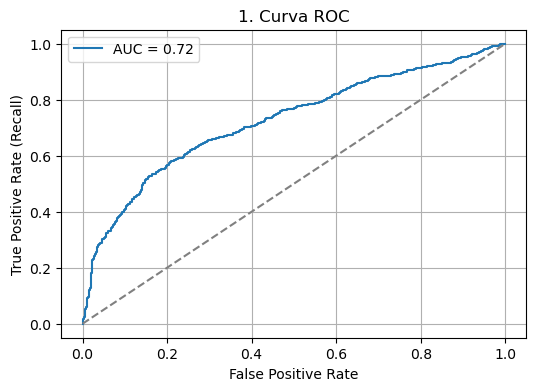

c:\Users\ntama\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ntama\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ntama\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


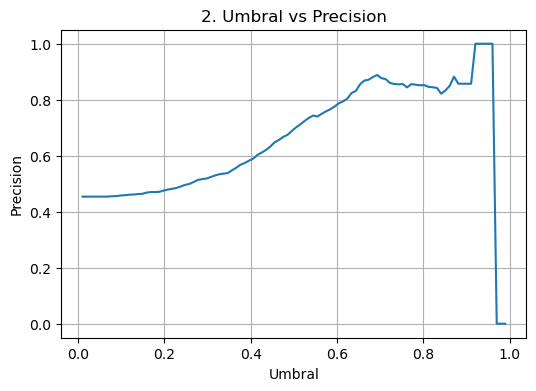

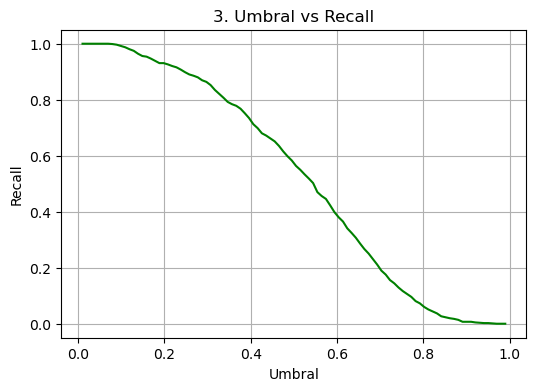

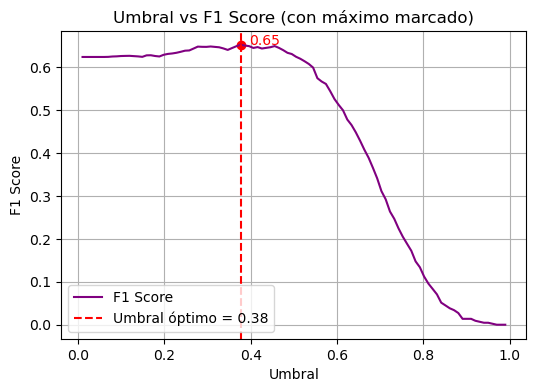

In [80]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = labels_test

#CURVA ROC + AUC
fpr, tpr, thresholds_roc = roc_curve(y_true, labels_test_predict_prob)
auc_score = roc_auc_score(y_true, labels_test_predict_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("1. Curva ROC")
plt.legend()
plt.grid()
plt.show()

#Precision, Recall y F1 vs Umbral
thresholds = np.linspace(0.01, 0.99, 100)
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred = (labels_test_predict_prob >= t).astype(int)
    precisions.append(precision_score(y_true, y_pred))
    recalls.append(recall_score(y_true, y_pred))
    f1_scores.append(f1_score(y_true, y_pred))

#Umbral vs Precisión
plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel("Umbral")
plt.ylabel("Precision")
plt.title("2. Umbral vs Precision")
plt.grid()
plt.show()

#Umbral vs Recall
plt.figure(figsize=(6, 4))
plt.plot(thresholds, recalls, label='Recall', color='green')
plt.xlabel("Umbral")
plt.ylabel("Recall")
plt.title("3. Umbral vs Recall")
plt.grid()
plt.show()

idx_max = np.argmax(f1_scores)
umbral_max = thresholds[idx_max]
f1_max = f1_scores[idx_max]
#Umbral vs F1 Score
plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, label="F1 Score", color='purple')
plt.axvline(x=umbral_max, color='red', linestyle='--', label=f'Umbral óptimo = {umbral_max:.2f}')
plt.scatter([umbral_max], [f1_max], color='red')
plt.text(umbral_max + 0.02, f1_max, f"{f1_max:.2f}", color='red')
plt.xlabel("Umbral")
plt.ylabel("F1 Score")
plt.title("Umbral vs F1 Score (con máximo marcado)")
plt.legend()
plt.grid()
plt.show()


Evaluación de modelo final con umbral = 0.38, regularización L1 Ridge y C = 0.002

In [89]:
logr_final = LogisticRegression(penalty=None, fit_intercept=True)
logr_final.fit(predictors_train, labels_train.values.ravel())

final_labels_predict = logr_final.predict(predictors_test)
final_labels_predict_proba = logr_final.predict_proba(predictors_test)
final_labels_predict_class = (final_labels_predict_proba[:,1] > 0.38)

final_labels_train_predict = logr_final.predict(predictors_train)
final_labels_train_predict_proba = logr_final.predict_proba(predictors_train)
final_labels_train_predict_class = (final_labels_train_predict_proba[:,1] > 0.38)

print("Datos de prueba")
print(f"Accuracy Score, % total de predicciones correctas sobre todos los casos: {accuracy_score(labels_test, final_labels_predict_class)}")
print(f"Precision Score, % de positivos predichos por el modelo: {precision_score(labels_test, final_labels_predict_class)}")
print(f"Recall score % de positivos encontrados por el modelo respecto a los reales: {recall_score(labels_test, final_labels_predict_class)}")
print(f"f1 score: {f1_score(labels_test, labels_test_predict)}")
print("Datos de Entrenamiento")
print(f"Accuracy Score, % total de predicciones correctas sobre todos los casos: {accuracy_score(labels_train, final_labels_train_predict_class)}")
print(f"Precision Score, % de positivos predichos por el modelo: {precision_score(labels_train, final_labels_train_predict_class)}")
print(f"Recall score % de positivos encontrados por el modelo respecto a los reales: {recall_score(labels_train, final_labels_train_predict_class)}")
print(f"f1 score: {f1_score(labels_train, final_labels_train_predict_class)}")

Datos de prueba
Accuracy Score, % total de predicciones correctas sobre todos los casos: 0.6336477987421384
Precision Score, % de positivos predichos por el modelo: 0.572419774501301
Recall score % de positivos encontrados por el modelo respecto a los reales: 0.7621247113163973
f1 score: 0.6313131313131313
Datos de Entrenamiento
Accuracy Score, % total de predicciones correctas sobre todos los casos: 0.6201337003539127
Precision Score, % de positivos predichos por el modelo: 0.5534188034188035
Recall score % de positivos encontrados por el modelo respecto a los reales: 0.7622130665097115
f1 score: 0.6412478336221837
